# Person 3 — Content-based and hybrid recommenders

**Role:** Use item metadata to build a **content-based** recommender, then combine it with collaborative signals in **hybrid** systems, including explicit **cold-start** handling.

## How it works (CEO-simple)

- **Content-based:** “If you liked games about X, here are other games whose descriptions and metadata look like X.” This works even when almost nobody has rated a product yet, as long as we have text/metadata.
- **Hybrid:** Blend **who bought what** (collaborative) with **what the product is about** (content), so we are less blind when interactions are thin.
- **Cold-start:** **New users** (no history) get **popular** unseen items; **sparse users** use **more content** via the **switching** hybrid; **new items** can still be recommended from metadata via the content channel.

## Inputs (from Person 1)

From `data/processed/`:

- `train.csv`, `val.csv`, `metadata_clean.csv` (`item_id`, `content_text` built from title, description, features, brand, category, etc.)

**Do not** use `test.csv` here — reserved for Person 4’s final comparison.

In [1]:
from __future__ import annotations

import re
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Set, Tuple

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DEFAULT_RELEVANCE_THRESHOLD = 4.0
DEFAULT_K = 10



In [2]:
# Resolve repo root: run from repo root or from notebooks/
_cwd = Path.cwd()
if (_cwd / "data" / "processed").exists():
    REPO_ROOT = _cwd
elif (_cwd.parent / "data" / "processed").exists():
    REPO_ROOT = _cwd.parent
else:
    REPO_ROOT = _cwd

PROC_DIR = REPO_ROOT / "data" / "processed"
OUTPUT_DIR = REPO_ROOT / "models" / "person3_outputs"
FIG_DIR = OUTPUT_DIR / "figures"
DEMO_DIR = REPO_ROOT / "data" / "person3_demo"

# Use bundled tiny demo if full preprocessing outputs are missing (reproducible notebook run)
if not (PROC_DIR / "train.csv").exists() and DEMO_DIR.exists():
    PROC_DIR = DEMO_DIR
    print("NOTE: Using bundled demo data in data/person3_demo/ (replace with Person 1 processed CSVs for real results).")

K = 10
# Default hybrid settings (also used as midpoints in sweeps)
ALPHA_CF = 0.6
MIN_HISTORY_FOR_CF = 5

MAX_FEATURES = 30000
NGRAM_RANGE = (1, 2)

# Sweeps (hybrid uses one fitted content+CF model; only α / threshold change at recommend time)
ALPHA_VALUES = [0.3, 0.5, 0.6, 0.7, 0.9]
SWITCHING_THRESHOLDS = [3, 5, 10, 15]

print("REPO_ROOT:", REPO_ROOT.resolve())
print("PROC_DIR:", PROC_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())



NOTE: Using bundled demo data in data/person3_demo/ (replace with Person 1 processed CSVs for real results).
REPO_ROOT: C:\Users\erive\Documents\IE\Chatbots\Chatbots project\recsys-amazon-videogames
PROC_DIR: C:\Users\erive\Documents\IE\Chatbots\Chatbots project\recsys-amazon-videogames\data\person3_demo
OUTPUT_DIR: C:\Users\erive\Documents\IE\Chatbots\Chatbots project\recsys-amazon-videogames\models\person3_outputs


## Review item metadata

Person 1 builds **`content_text`** from **title**, **description**, **features**, **brand**, and **categories** into one searchable profile.

**Which fields matter for our models?**

| Signal | Role |
| --- | --- |
| Title + description + features | Core vocabulary for TF-IDF / BoW similarity between games |
| Brand / publisher | Often captured in `content_text`; helps series/franchise similarity |
| Categories (main/sub) | Structure the catalog; useful for sanity checks and plots |

We explore distributions below; the **recommendation models** consume the pre-merged `content_text` column (plus collaborative signals in hybrids).


Shape: (10, 6)
Columns: ['item_id', 'title', 'brand', 'main_category', 'sub_category', 'content_text']


,item_id,title,brand,main_category,sub_category
0,i1,Mario Kart 8 Deluxe,Nintendo,Racing,Switch
1,i2,The Legend of Zelda,Nintendo,Adventure,Switch
2,i3,Call of Duty: Modern Warfare,Activision,Shooter,PS4
3,i4,FIFA 24,EA,Sports,PS5
4,i5,Animal Crossing,Nintendo,Simulation,Switch
5,i6,Elden Ring,FromSoftware,RPG,PS5
6,i7,Minecraft,Mojang,Sandbox,Multi
7,i8,Grand Theft Auto V,Rockstar,Action,PS4



content_text length — min / median / max: 37 44.5 50
Share empty content_text: 0.00%


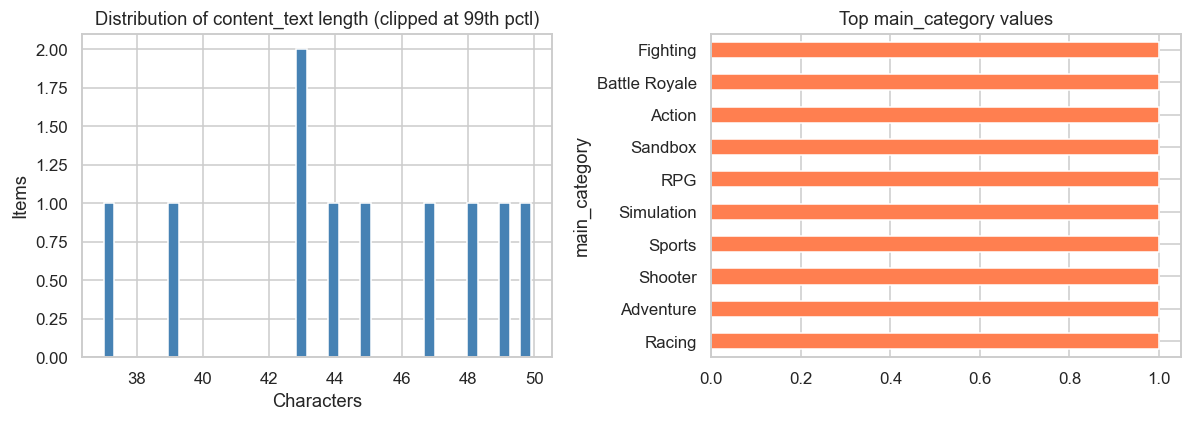

In [3]:
_meta_path = PROC_DIR / "metadata_clean.csv"
if not _meta_path.exists():
    raise FileNotFoundError(f"Expected {_meta_path}")

meta_explore = pd.read_csv(_meta_path)
print("Shape:", meta_explore.shape)
print("Columns:", list(meta_explore.columns))

# Example rows (readable)
show_cols = [c for c in ["item_id", "title", "brand", "main_category", "sub_category"] if c in meta_explore.columns]
if show_cols:
    display(meta_explore[show_cols].head(8))
else:
    display(meta_explore.head(8))

if "content_text" in meta_explore.columns:
    raw_len = meta_explore["content_text"].fillna("").astype(str).str.len()
    print(
        "\ncontent_text length — min / median / max:",
        int(raw_len.min()),
        float(raw_len.median()),
        int(raw_len.max()),
    )
    print(f"Share empty content_text: {(raw_len == 0).mean():.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(np.clip(raw_len, 0, np.percentile(raw_len, 99)), bins=40, color="steelblue", edgecolor="white")
    axes[0].set_title("Distribution of content_text length (clipped at 99th pctl)")
    axes[0].set_xlabel("Characters")
    axes[0].set_ylabel("Items")

    if "main_category" in meta_explore.columns:
        top_cat = meta_explore["main_category"].fillna("unknown").value_counts().head(12)
        top_cat.plot(kind="barh", ax=axes[1], color="coral")
        axes[1].set_title("Top main_category values")
    else:
        axes[1].text(0.1, 0.5, "No main_category column in this export", transform=axes[1].transAxes)
        axes[1].set_axis_off()

    plt.tight_layout()
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "fig_metadata_overview.png", bbox_inches="tight")
    plt.show()
else:
    print("No content_text column found.")



## Implementation

**Pipeline:** `_clean_text` → optional **WordNet lemmatization** → **TF-IDF** or **BoW** → **cosine** item similarity (`linear_kernel`).

**Hybrids:** weighted blend of normalized content vs item–item CF scores; switching sends low-history users to content-first.

Metrics, recommender class, and helpers:

In [4]:
def _clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [tok for tok in text.split() if tok and tok not in ENGLISH_STOP_WORDS]
    return " ".join(tokens)


def _lemmatize_corpus(series: pd.Series) -> pd.Series:
    """Optional: WordNet lemmas (uses nltk; downloads corpora on first use)."""
    try:
        import nltk
        from nltk.stem import WordNetLemmatizer

        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)
        lem = WordNetLemmatizer()

        def _lemmatize_one(s: str) -> str:
            if not s:
                return ""
            return " ".join(lem.lemmatize(tok) for tok in str(s).split())

        return series.map(_lemmatize_one)
    except Exception as exc:
        print("Lemmatization skipped:", exc)
        return series


def precision_at_k(recommended: List[str], relevant: Set[str], k: int) -> float:
    if k <= 0:
        return 0.0
    rec_set = set(recommended[:k])
    return len(rec_set.intersection(relevant)) / k


def recall_at_k(recommended: List[str], relevant: Set[str], k: int) -> float:
    if not relevant:
        return 0.0
    rec_set = set(recommended[:k])
    return len(rec_set.intersection(relevant)) / len(relevant)


def ndcg_at_k(recommended: List[str], relevant: Set[str], k: int) -> float:
    if not relevant:
        return 0.0
    recs = recommended[:k]
    discounts = np.log2(np.arange(2, len(recs) + 2))
    gains = np.array([1.0 if item in relevant else 0.0 for item in recs], dtype=float)
    dcg = np.sum(gains / discounts)

    ideal_len = min(len(relevant), k)
    ideal_discounts = np.log2(np.arange(2, ideal_len + 2))
    idcg = np.sum(np.ones(ideal_len) / ideal_discounts)
    return float(dcg / idcg) if idcg > 0 else 0.0


def ap_at_k(recommended: List[str], relevant: Set[str], k: int) -> float:
    if not relevant:
        return 0.0
    hits = 0
    sum_precision = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in relevant:
            hits += 1
            sum_precision += hits / (i + 1)
    return sum_precision / min(len(relevant), k)


@dataclass
class DataBundle:
    train: pd.DataFrame
    val: pd.DataFrame
    metadata: pd.DataFrame


class ContentHybridRecommender:
    def __init__(
        self,
        data: DataBundle,
        relevance_threshold: float = DEFAULT_RELEVANCE_THRESHOLD,
    ) -> None:
        self.train = data.train.copy()
        self.val = data.val.copy()
        self.metadata = data.metadata.copy()
        self.relevance_threshold = relevance_threshold

        self._validate_required_columns()
        self._prepare_ids_as_str()

        self.item_ids: np.ndarray = self.metadata["item_id"].values
        self.item_id_to_idx: Dict[str, int] = {iid: i for i, iid in enumerate(self.item_ids)}
        self.user_seen_train: Dict[str, Set[str]] = (
            self.train.groupby("user_id")["item_id"].apply(set).to_dict()
        )
        self.user_train_count: Dict[str, int] = self.train.groupby("user_id").size().to_dict()
        self.user_val_relevant: Dict[str, Set[str]] = (
            self.val[self.val["rating"] >= self.relevance_threshold]
            .groupby("user_id")["item_id"]
            .apply(set)
            .to_dict()
        )
        self.eval_users: List[str] = sorted(
            [u for u, rel in self.user_val_relevant.items() if rel and u in self.user_seen_train]
        )

        self.popular_items: List[str] = (
            self.train.groupby("item_id")
            .size()
            .sort_values(ascending=False)
            .index.astype(str)
            .tolist()
        )

        self.tfidf_vectorizer: TfidfVectorizer | None = None
        self.item_tfidf: csr_matrix | None = None
        self.content_sim: np.ndarray | None = None
        self.item_cf_sim: np.ndarray | None = None

    def _validate_required_columns(self) -> None:
        train_req = {"user_id", "item_id", "rating"}
        val_req = {"user_id", "item_id", "rating"}
        meta_req = {"item_id"}
        if "content_text" not in self.metadata.columns:
            missing_meta = meta_req.union({"content_text"}) - set(self.metadata.columns)
            raise ValueError(
                f"metadata_clean.csv missing required columns: {sorted(missing_meta)}. "
                "Expected at least ['item_id', 'content_text']."
            )

        missing_train = train_req - set(self.train.columns)
        missing_val = val_req - set(self.val.columns)
        if missing_train:
            raise ValueError(f"train.csv missing required columns: {sorted(missing_train)}")
        if missing_val:
            raise ValueError(f"val.csv missing required columns: {sorted(missing_val)}")

    def _prepare_ids_as_str(self) -> None:
        for df in (self.train, self.val, self.metadata):
            df["user_id"] = df["user_id"].astype(str) if "user_id" in df.columns else None
            df["item_id"] = df["item_id"].astype(str)
        self.metadata["content_text"] = (
            self.metadata["content_text"].fillna("").astype(str).map(_clean_text)
        )

    def fit_content(
        self,
        max_features: int = 30000,
        ngram_range: Tuple[int, int] = (1, 2),
        vectorizer: str = "tfidf",
        use_lemmatization: bool = False,
    ) -> None:
        """Build item–item content similarity using TF-IDF or bag-of-words + cosine (linear_kernel on L2-normalized TF-IDF)."""
        corpus = self.metadata["content_text"]
        if use_lemmatization:
            corpus = _lemmatize_corpus(corpus)
        kind = (vectorizer or "tfidf").lower()
        if kind == "tfidf":
            self.tfidf_vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        elif kind == "bow":
            self.tfidf_vectorizer = CountVectorizer(max_features=max_features, ngram_range=ngram_range)
        else:
            raise ValueError("vectorizer must be 'tfidf' or 'bow'")
        self.item_tfidf = self.tfidf_vectorizer.fit_transform(corpus)
        self.content_sim = linear_kernel(self.item_tfidf, self.item_tfidf)

    def fit_item_cf(self) -> None:
        users = self.train["user_id"].astype("category")
        items = self.train["item_id"].astype("category")
        rows = users.cat.codes.values
        cols = items.cat.codes.values
        vals = np.ones(len(self.train), dtype=np.float32)

        user_item = csr_matrix((vals, (rows, cols)), shape=(users.cat.categories.size, items.cat.categories.size))
        item_user = user_item.T
        cf_sim = linear_kernel(item_user, item_user)

        item_order = items.cat.categories.astype(str).tolist()
        cf_index = {iid: idx for idx, iid in enumerate(item_order)}

        full_sim = np.zeros((len(self.item_ids), len(self.item_ids)), dtype=np.float32)
        for i, iid_i in enumerate(self.item_ids):
            if iid_i not in cf_index:
                continue
            row_i = cf_index[iid_i]
            for j, iid_j in enumerate(self.item_ids):
                if iid_j not in cf_index:
                    continue
                full_sim[i, j] = cf_sim[row_i, cf_index[iid_j]]
        self.item_cf_sim = full_sim

    def _top_popular_unseen(self, seen: Set[str], k: int) -> List[str]:
        return [item for item in self.popular_items if item not in seen][:k]

    def recommend_content(self, user_id: str, k: int = DEFAULT_K) -> List[str]:
        if self.content_sim is None:
            raise RuntimeError("fit_content() must be called before recommend_content().")
        seen = self.user_seen_train.get(user_id, set())
        if not seen:
            return self._top_popular_unseen(seen, k)

        seen_idx = [self.item_id_to_idx[i] for i in seen if i in self.item_id_to_idx]
        if not seen_idx:
            return self._top_popular_unseen(seen, k)

        content_scores = self.content_sim[seen_idx].mean(axis=0)
        ranked_idx = np.argsort(content_scores)[::-1]
        recs: List[str] = []
        for idx in ranked_idx:
            iid = self.item_ids[idx]
            if iid in seen:
                continue
            recs.append(iid)
            if len(recs) >= k:
                break
        if len(recs) < k:
            recs.extend(self._top_popular_unseen(seen.union(set(recs)), k - len(recs)))
        return recs

    def recommend_weighted_hybrid(
        self,
        user_id: str,
        k: int = DEFAULT_K,
        alpha_cf: float = 0.6,
    ) -> List[str]:
        if self.content_sim is None or self.item_cf_sim is None:
            raise RuntimeError("fit_content() and fit_item_cf() must be called before hybrid recommendations.")
        seen = self.user_seen_train.get(user_id, set())
        if not seen:
            return self._top_popular_unseen(seen, k)

        seen_idx = [self.item_id_to_idx[i] for i in seen if i in self.item_id_to_idx]
        if not seen_idx:
            return self._top_popular_unseen(seen, k)

        content_scores = self.content_sim[seen_idx].mean(axis=0).reshape(-1, 1)
        cf_scores = self.item_cf_sim[seen_idx].mean(axis=0).reshape(-1, 1)

        scaler = MinMaxScaler()
        content_norm = scaler.fit_transform(content_scores).ravel()
        cf_norm = scaler.fit_transform(cf_scores).ravel()

        hybrid_scores = alpha_cf * cf_norm + (1.0 - alpha_cf) * content_norm
        ranked_idx = np.argsort(hybrid_scores)[::-1]

        recs: List[str] = []
        for idx in ranked_idx:
            iid = self.item_ids[idx]
            if iid in seen:
                continue
            recs.append(iid)
            if len(recs) >= k:
                break
        if len(recs) < k:
            recs.extend(self._top_popular_unseen(seen.union(set(recs)), k - len(recs)))
        return recs

    def recommend_switching_hybrid(
        self,
        user_id: str,
        k: int = DEFAULT_K,
        min_history_for_cf: int = 5,
        alpha_cf: float = 0.6,
    ) -> List[str]:
        history_len = self.user_train_count.get(user_id, 0)
        if history_len >= min_history_for_cf:
            return self.recommend_weighted_hybrid(user_id=user_id, k=k, alpha_cf=alpha_cf)
        return self.recommend_content(user_id=user_id, k=k)

    def evaluate(self, model_name: str, recommend_fn, k: int = DEFAULT_K) -> Dict[str, float]:
        precisions, recalls, ndcgs, maps = [], [], [], []
        all_recommended = set()

        for user_id in self.eval_users:
            relevant = self.user_val_relevant.get(user_id, set())
            recs = recommend_fn(user_id, k)
            all_recommended.update(recs)
            precisions.append(precision_at_k(recs, relevant, k))
            recalls.append(recall_at_k(recs, relevant, k))
            ndcgs.append(ndcg_at_k(recs, relevant, k))
            maps.append(ap_at_k(recs, relevant, k))

        coverage = len(all_recommended) / len(self.item_ids) if len(self.item_ids) else 0.0
        return {
            "model": model_name,
            "precision_at_k": float(np.mean(precisions)) if precisions else 0.0,
            "recall_at_k": float(np.mean(recalls)) if recalls else 0.0,
            "ndcg_at_k": float(np.mean(ndcgs)) if ndcgs else 0.0,
            "map_at_k": float(np.mean(maps)) if maps else 0.0,
            "coverage": coverage,
            "eval_users": len(self.eval_users),
        }
def _prepare_ids_safe(train: pd.DataFrame, val: pd.DataFrame, metadata: pd.DataFrame) -> None:
    for df in (train, val):
        df["user_id"] = df["user_id"].astype(str)
        df["item_id"] = df["item_id"].astype(str)
    metadata["item_id"] = metadata["item_id"].astype(str)
    metadata["content_text"] = (
        metadata["content_text"].fillna("").astype(str).map(_clean_text)
    )


class ContentHybridRecommenderNB(ContentHybridRecommender):
    def _prepare_ids_as_str(self) -> None:
        _prepare_ids_safe(self.train, self.val, self.metadata)


def load_data_nb(processed_dir: Path) -> DataBundle:
    train_path = processed_dir / "train.csv"
    val_path = processed_dir / "val.csv"
    metadata_path = processed_dir / "metadata_clean.csv"
    missing = [p.name for p in (train_path, val_path, metadata_path) if not p.exists()]
    if missing:
        raise FileNotFoundError(
            f"Missing required files in {processed_dir}: {missing}. "
            "Run Person 1 preprocessing first, then rerun this notebook."
        )
    return DataBundle(
        train=pd.read_csv(train_path),
        val=pd.read_csv(val_path),
        metadata=pd.read_csv(metadata_path),
    )



## Fit, compare, evaluate, save

**Validation protocol:** same as Person 2 — top-K **unseen** train items per user; **relevant** if rating ≥ 4 in `val.csv`.

Sections below: (1) content TF-IDF vs BoW vs lemmatized TF-IDF, (2) hybrid **α** sweep, (3) **switching** threshold sweep, (4) exports + **titles** on sample recommendations.

In [5]:
data = load_data_nb(PROC_DIR)

# Titles for readable recommendations (from raw metadata before cleaning in bundle)
_meta_raw = pd.read_csv(PROC_DIR / "metadata_clean.csv")
item_titles = {}
if "title" in _meta_raw.columns:
    item_titles = _meta_raw.set_index(_meta_raw["item_id"].astype(str))["title"].to_dict()
else:
    item_titles = {str(r["item_id"]): str(r.get("item_id", "")) for _, r in _meta_raw.iterrows()}

def title_of(iid: str) -> str:
    return str(item_titles.get(str(iid), iid))

print("Users in train:", data.train["user_id"].nunique(), "| Items in metadata:", len(item_titles))



Users in train: 10 | Items in metadata: 10


\n=== Content representation comparison (validation) ===


,model,precision_at_k,recall_at_k,ndcg_at_k,map_at_k,coverage,eval_users
0,content_tfidf,0.12,1.0,0.452030,0.281905,1.0,10
2,content_tfidf_lemmatized,0.12,1.0,0.452030,0.281905,1.0,10
1,content_bow,0.12,1.0,0.446551,0.274524,1.0,10


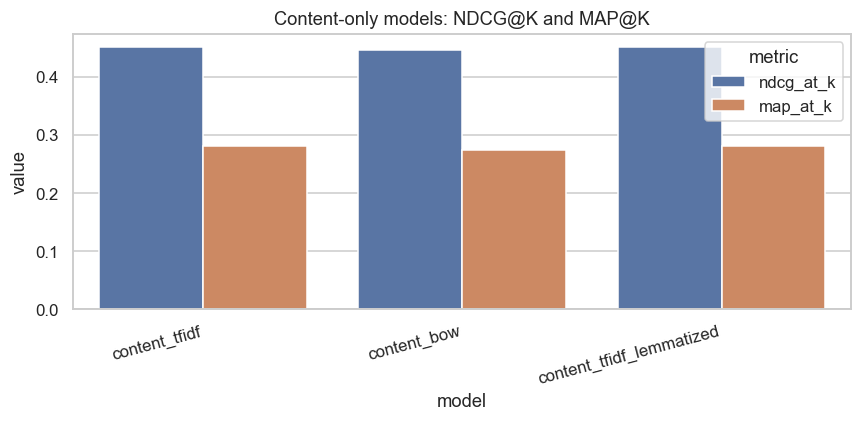

\nBest content-only by NDCG@K: content_tfidf


In [6]:
# --- 1) Content-only: TF-IDF vs BoW vs lemmatized TF-IDF ---
content_rows = []

def eval_content(name: str, r: ContentHybridRecommenderNB) -> None:
    row = r.evaluate(
        model_name=name,
        recommend_fn=lambda u, k, rr=r: rr.recommend_content(user_id=u, k=k),
        k=K,
    )
    content_rows.append(row)

r_tfidf = ContentHybridRecommenderNB(data=data)
r_tfidf.fit_content(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, vectorizer="tfidf", use_lemmatization=False)
eval_content("content_tfidf", r_tfidf)

r_bow = ContentHybridRecommenderNB(data=data)
r_bow.fit_content(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, vectorizer="bow", use_lemmatization=False)
eval_content("content_bow", r_bow)

r_lem = ContentHybridRecommenderNB(data=data)
r_lem.fit_content(max_features=MAX_FEATURES, ngram_range=NGRAM_RANGE, vectorizer="tfidf", use_lemmatization=True)
eval_content("content_tfidf_lemmatized", r_lem)

df_content = pd.DataFrame(content_rows)
print("\\n=== Content representation comparison (validation) ===")
display(df_content.sort_values("ndcg_at_k", ascending=False))

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = df_content.melt(
    id_vars=["model"],
    value_vars=["ndcg_at_k", "map_at_k"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=plot_df, x="model", y="value", hue="metric", ax=ax)
ax.set_title("Content-only models: NDCG@K and MAP@K")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "fig_content_tfidf_vs_bow_vs_lemma.png", bbox_inches="tight")
plt.show()

best_content = df_content.loc[df_content["ndcg_at_k"].idxmax(), "model"]
print(f"\\nBest content-only by NDCG@K: {best_content}")



=== Weighted hybrid: α sweep ===

,model,ndcg_at_k,map_at_k,precision_at_k
0,hybrid_weighted_alpha_0.3,0.506605,0.350952,0.12
1,hybrid_weighted_alpha_0.5,0.545291,0.400952,0.12
2,hybrid_weighted_alpha_0.6,0.549541,0.409286,0.12
3,hybrid_weighted_alpha_0.7,0.549541,0.409286,0.12
4,hybrid_weighted_alpha_0.9,0.549541,0.409286,0.12


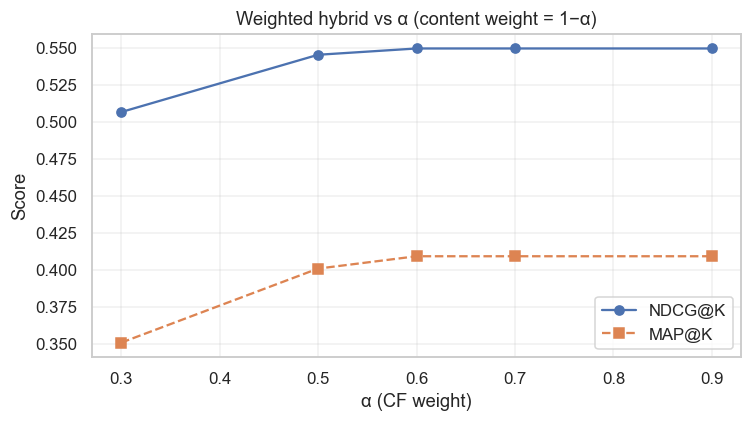

Best α by NDCG@K: 0.6


In [7]:
# --- 2) Hybrid: use standard TF-IDF + item-item CF (same as Person 2 spirit) ---
recommender = ContentHybridRecommenderNB(data=data)
recommender.fit_content(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    vectorizer="tfidf",
    use_lemmatization=False,
)
recommender.fit_item_cf()

# α sweep (no refit; same matrices)
alpha_rows = []
for a in ALPHA_VALUES:
    alpha_rows.append(
        recommender.evaluate(
            model_name=f"hybrid_weighted_alpha_{a}",
            recommend_fn=lambda u, k, rr=recommender, aa=a: rr.recommend_weighted_hybrid(
                user_id=u, k=k, alpha_cf=aa
            ),
            k=K,
        )
    )
df_alpha = pd.DataFrame(alpha_rows)
print("=== Weighted hybrid: α sweep ===")
display(df_alpha[["model", "ndcg_at_k", "map_at_k", "precision_at_k"]])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_alpha["model"].str.replace("hybrid_weighted_alpha_", "").astype(float), df_alpha["ndcg_at_k"], "o-", label="NDCG@K")
ax.plot(df_alpha["model"].str.replace("hybrid_weighted_alpha_", "").astype(float), df_alpha["map_at_k"], "s--", label="MAP@K")
ax.set_xlabel("α (CF weight)")
ax.set_ylabel("Score")
ax.set_title("Weighted hybrid vs α (content weight = 1−α)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_hybrid_alpha_sweep.png", bbox_inches="tight")
plt.show()

best_alpha_row = df_alpha.loc[df_alpha["ndcg_at_k"].idxmax()]
ALPHA_CF = float(best_alpha_row["model"].replace("hybrid_weighted_alpha_", ""))
print(f"Best α by NDCG@K: {ALPHA_CF}")



=== Switching hybrid: min history threshold ===


,model,ndcg_at_k,map_at_k
0,hybrid_switching_th_3,0.499844,0.340952
1,hybrid_switching_th_5,0.452030,0.281905
2,hybrid_switching_th_10,0.452030,0.281905
3,hybrid_switching_th_15,0.452030,0.281905


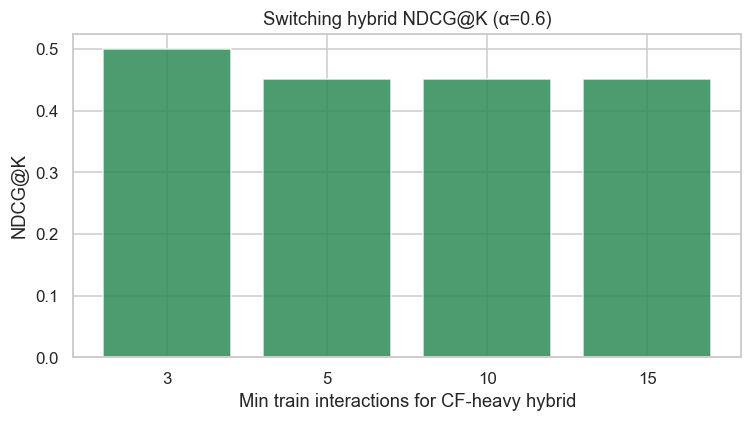

Best switching threshold by NDCG@K: 3


In [8]:
# --- 3) Switching threshold sweep (uses best α from previous cell) ---
sw_rows = []
for th in SWITCHING_THRESHOLDS:
    sw_rows.append(
        recommender.evaluate(
            model_name=f"hybrid_switching_th_{th}",
            recommend_fn=lambda u, k, rr=recommender, t=th: rr.recommend_switching_hybrid(
                user_id=u, k=k, min_history_for_cf=t, alpha_cf=ALPHA_CF
            ),
            k=K,
        )
    )
df_sw = pd.DataFrame(sw_rows)
print("=== Switching hybrid: min history threshold ===")
display(df_sw[["model", "ndcg_at_k", "map_at_k"]])

fig, ax = plt.subplots(figsize=(7, 4))
th_x = [int(m.split("_th_")[1]) for m in df_sw["model"]]
ax.bar(range(len(th_x)), df_sw["ndcg_at_k"], color="seagreen", alpha=0.85)
ax.set_xticks(range(len(th_x)))
ax.set_xticklabels(th_x)
ax.set_xlabel("Min train interactions for CF-heavy hybrid")
ax.set_ylabel("NDCG@K")
ax.set_title(f"Switching hybrid NDCG@K (α={ALPHA_CF})")
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_switching_threshold_sweep.png", bbox_inches="tight")
plt.show()

best_th = int(df_sw.loc[df_sw["ndcg_at_k"].idxmax(), "model"].split("_th_")[1])
MIN_HISTORY_FOR_CF = best_th
print(f"Best switching threshold by NDCG@K: {MIN_HISTORY_FOR_CF}")



,user_id,recommendations
0,u1,FIFA 24 (i4) | Super Smash Bros (i10) | Animal...
1,u10,Mario Kart 8 Deluxe (i1) | Grand Theft Auto V ...
2,u2,Call of Duty: Modern Warfare (i3) | Mario Kart...
3,u3,Super Smash Bros (i10) | The Legend of Zelda (...
4,u4,Grand Theft Auto V (i8) | Animal Crossing (i5)...
5,u5,Minecraft (i7) | Super Smash Bros (i10) | Call...
6,u6,The Legend of Zelda (i2) | Animal Crossing (i5...
7,u7,The Legend of Zelda (i2) | Mario Kart 8 Deluxe...
8,u8,Mario Kart 8 Deluxe (i1) | Minecraft (i7) | Th...
9,u9,Elden Ring (i6) | Fortnite (i9) | The Legend o...


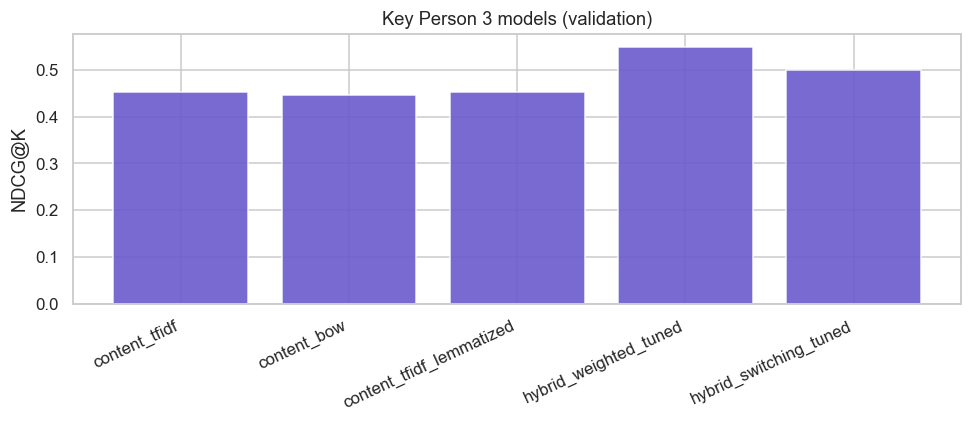

Saved: C:\Users\erive\Documents\IE\Chatbots\Chatbots project\recsys-amazon-videogames\models\person3_outputs\person3_model_results.csv
Figures: C:\Users\erive\Documents\IE\Chatbots\Chatbots project\recsys-amazon-videogames\models\person3_outputs\figures


In [9]:
# --- 4) Merge results, save CSVs, human-readable sample recs ---
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Final "production" metrics using tuned α and threshold from sweeps
final_rows = [
    recommender.evaluate(
        model_name="hybrid_weighted_tuned",
        recommend_fn=lambda u, k, rr=recommender: rr.recommend_weighted_hybrid(user_id=u, k=k, alpha_cf=ALPHA_CF),
        k=K,
    ),
    recommender.evaluate(
        model_name="hybrid_switching_tuned",
        recommend_fn=lambda u, k, rr=recommender: rr.recommend_switching_hybrid(
            user_id=u, k=k, min_history_for_cf=MIN_HISTORY_FOR_CF, alpha_cf=ALPHA_CF
        ),
        k=K,
    ),
]

results_full = pd.concat(
    [df_content, df_alpha, df_sw, pd.DataFrame(final_rows)],
    ignore_index=True,
)
results_full.to_csv(OUTPUT_DIR / "person3_model_results.csv", index=False)
df_content.to_csv(OUTPUT_DIR / "person3_content_comparison.csv", index=False)
df_alpha.to_csv(OUTPUT_DIR / "person3_alpha_sweep.csv", index=False)
df_sw.to_csv(OUTPUT_DIR / "person3_switching_sweep.csv", index=False)
pd.DataFrame(final_rows).to_csv(OUTPUT_DIR / "person3_final_tuned_metrics.csv", index=False)

# Sample recommendations with titles
sample_users = recommender.eval_users[: min(10, len(recommender.eval_users))]
readable = []
for u in sample_users:
    ids = recommender.recommend_weighted_hybrid(u, K, ALPHA_CF)
    readable.append(
        {
            "user_id": u,
            "recommendations": " | ".join(f"{title_of(i)} ({i})" for i in ids),
        }
    )
sample_df = pd.DataFrame(readable)
sample_df.to_csv(OUTPUT_DIR / "person3_sample_recommendations_titles.csv", index=False)
display(sample_df)

# Summary chart: key models
summary_models = [
    "content_tfidf",
    "content_bow",
    "content_tfidf_lemmatized",
    "hybrid_weighted_tuned",
    "hybrid_switching_tuned",
]
key_df = results_full[results_full["model"].isin(summary_models)].copy()
if key_df.empty:
    key_df = results_full.tail(8)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(key_df))
ax.bar(x, key_df["ndcg_at_k"], color="slateblue", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(key_df["model"], rotation=25, ha="right")
ax.set_ylabel("NDCG@K")
ax.set_title("Key Person 3 models (validation)")
plt.tight_layout()
fig.savefig(FIG_DIR / "fig_key_models_ndcg.png", bbox_inches="tight")
plt.show()

print("Saved:", OUTPUT_DIR / "person3_model_results.csv")
print("Figures:", FIG_DIR)



## Interpretation (for report)

- **TF-IDF vs BoW:** TF-IDF usually wins when rare discriminative terms matter; BoW can work on very short text.
- **Lemmatization:** Can help vocabulary match; not always better if it removes useful game-specific tokens.
- **α:** Higher α trusts collaborative co-interaction more; lower α leans on metadata when CF is noisy.
- **Switching threshold:** Lower → more users get CF-heavy hybrid sooner; higher → more content/popularity for cold/sparse users.
- **Demo data:** Bundled `data/person3_demo/` is only for runnable outputs; **replace with Person 1 `data/processed/`** for your real report numbers.